# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 04     |  |
| :-------------|:-------------|
| Sriman Patlolla| 6393829 |
| Juraj Hadak| 5989779 |
| Carsten Schroevers| 6126634 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sriman', 'Juraj']#'Carsten']

## Opdracht 1: Planning.

| Planning Groep: 04     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding af Arduino opzetten | 11.30 |
| Kalibratie en testen | 12.00 |
|  Zelf algoritme schrijven | 12.30 |
| Iteraties en testen | 15.00 |
| Eindtest en afronden | 16.30 |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12.30-13.30 |
| Pauze 2|  |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [04]
<img src="Foto.jpeg" width="400">

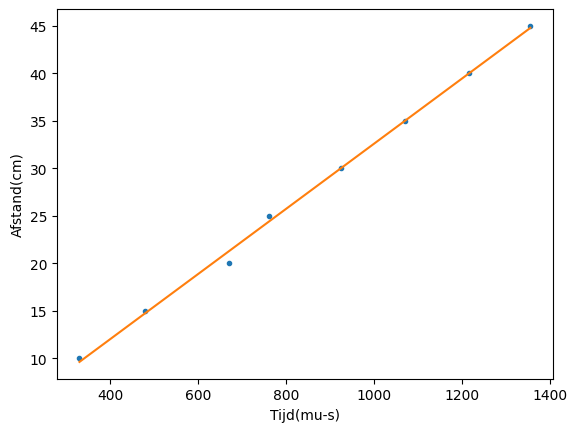

a en b zijn: [ 0.03429911 -1.68425201]


In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

Afstand = np.array([10,15,20,25,30,35,40,45])
Tijd = np.array([330,480,670,761,925,1070,1216,1355])

def func(x,a,b):
    return a*x+b

popt, pcov = curve_fit(func, Tijd, Afstand)

Tijd_test = np.linspace(np.min(Tijd), np.max(Tijd),100)
Af_test = func(Tijd_test, *popt)

plt.figure()
plt.plot(Tijd, Afstand,'.')
plt.plot(Tijd_test, Af_test)
plt.xlabel("Tijd(mu-s)")
plt.ylabel("Afstand(cm)")
plt.show()

print("a en b zijn:",popt)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  40.5
1   0  30   0  20  40.6
2   0  10   0  20  45.1
3  40   0  30   0  41.2
4  30   0  20   0  40.8
5  10   0  20   0  45.0
6  10   0   0  10  45.0


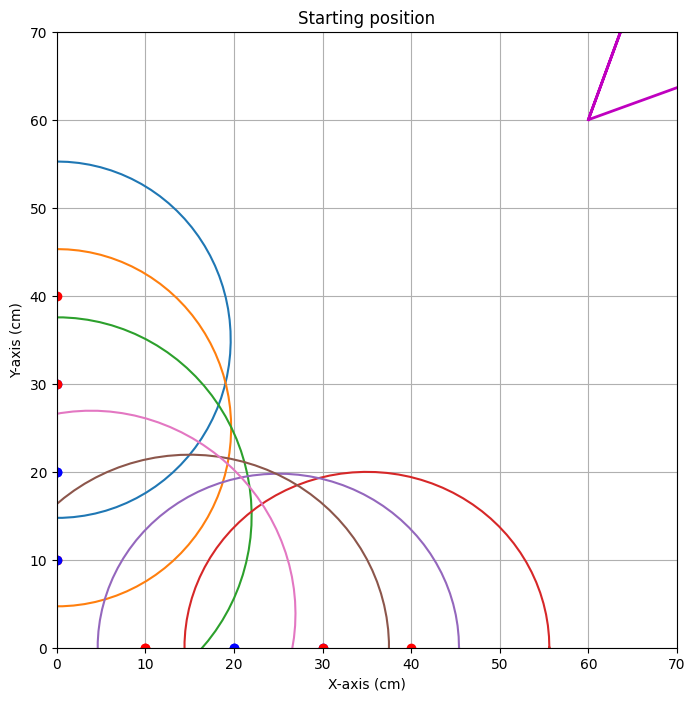


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=106.994


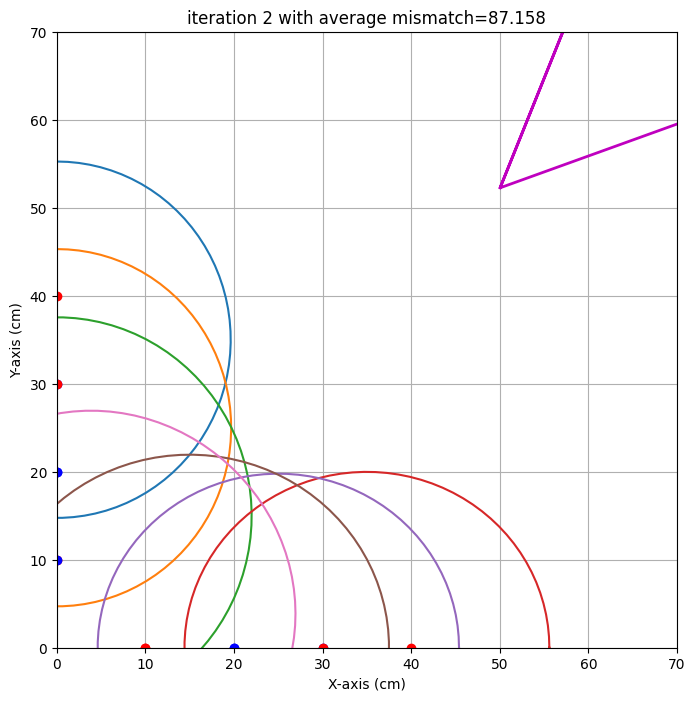

end iteration 2 with average mismatch=87.158


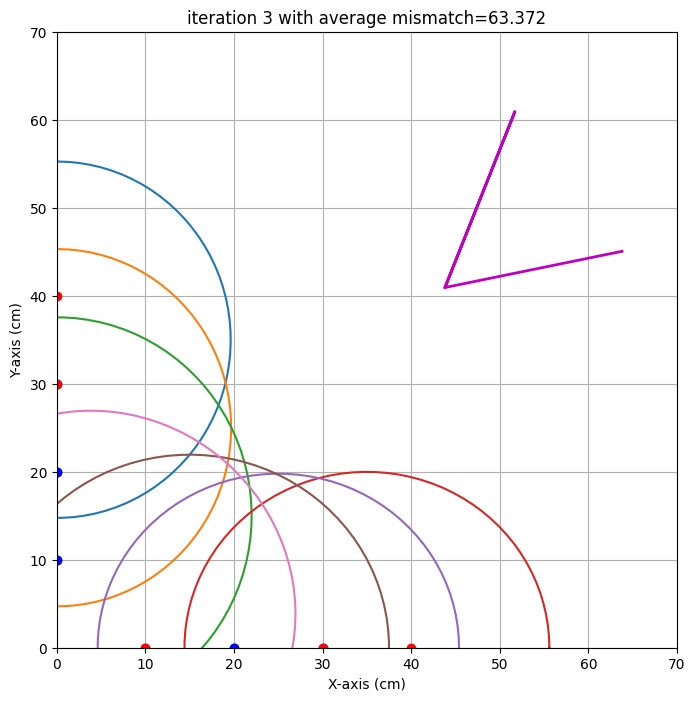

end iteration 3 with average mismatch=63.372


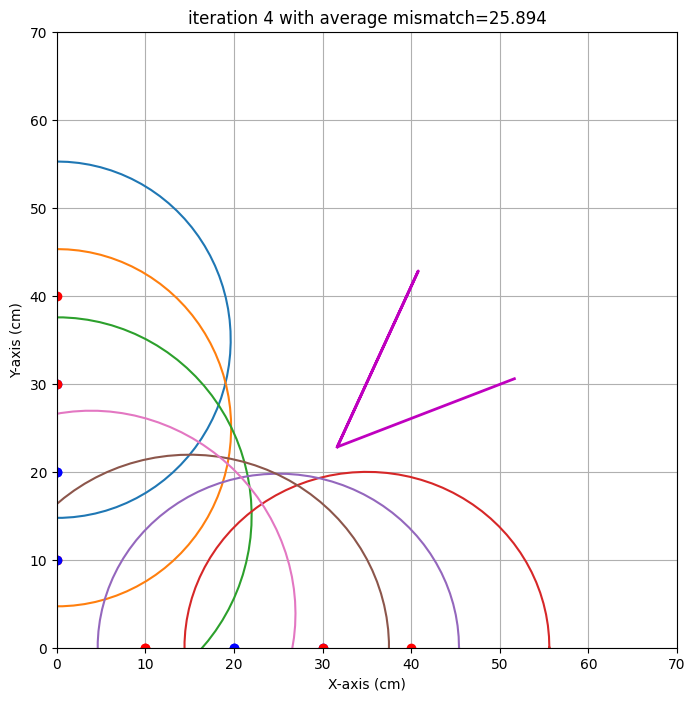

end iteration 4 with average mismatch=25.894


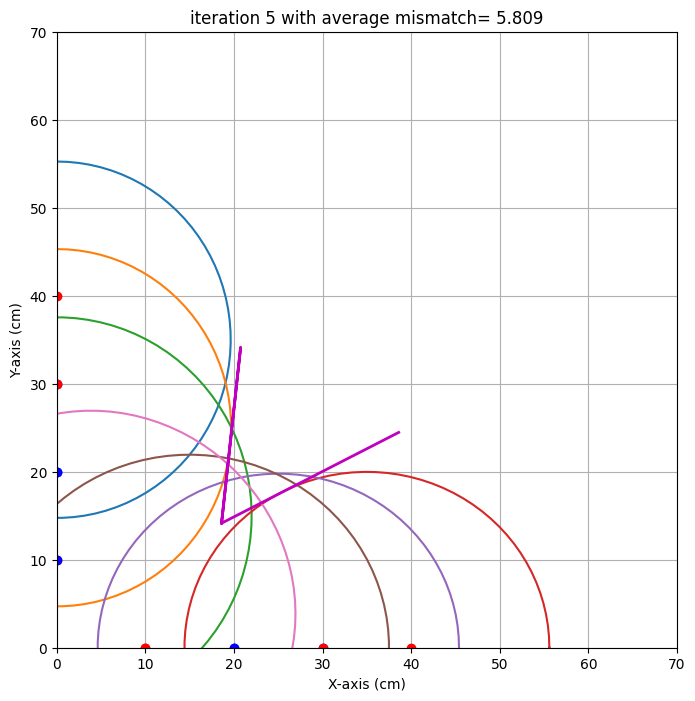

end iteration 5 with average mismatch= 5.809


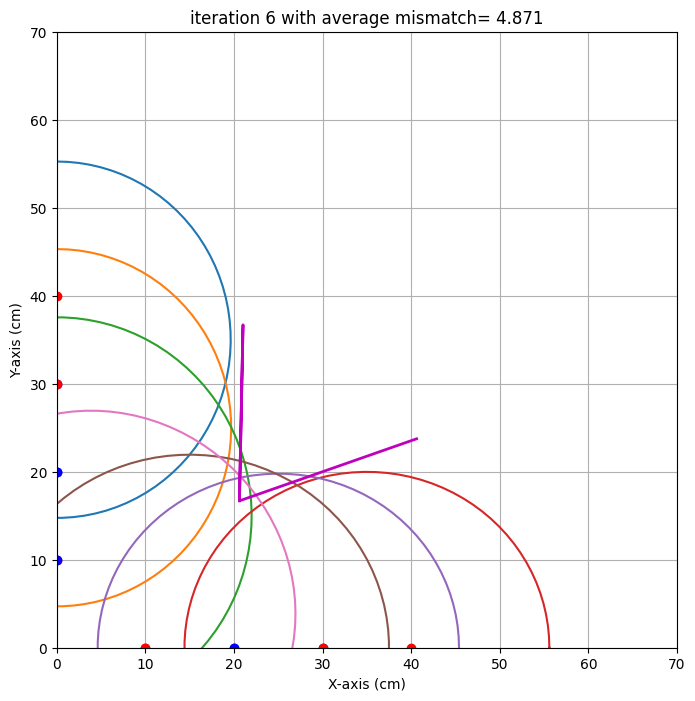

end iteration 6 with average mismatch= 4.871


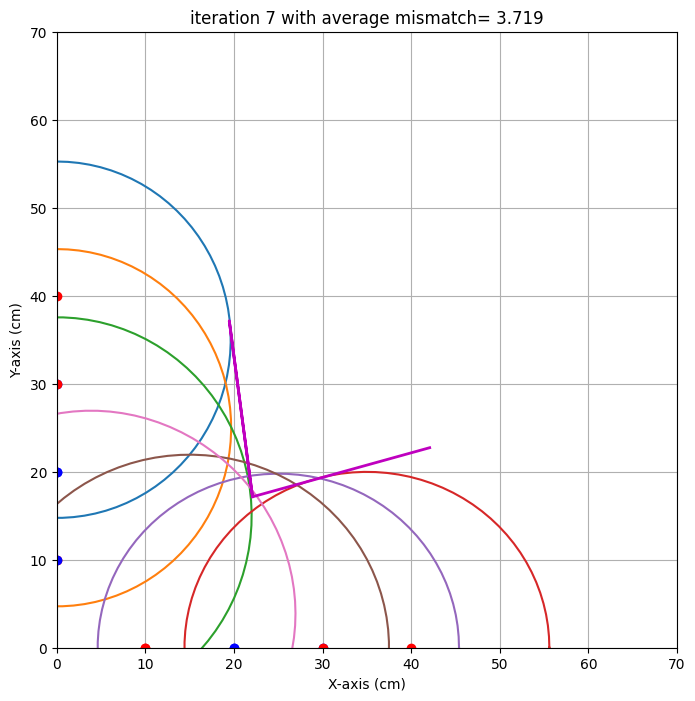

end iteration 7 with average mismatch= 3.719
end iteration 8 with average mismatch= 3.685
end iteration 9 with average mismatch= 3.593
end iteration 10 with average mismatch= 3.580
end iteration 11 with average mismatch= 3.577
end iteration 12 with average mismatch= 3.576


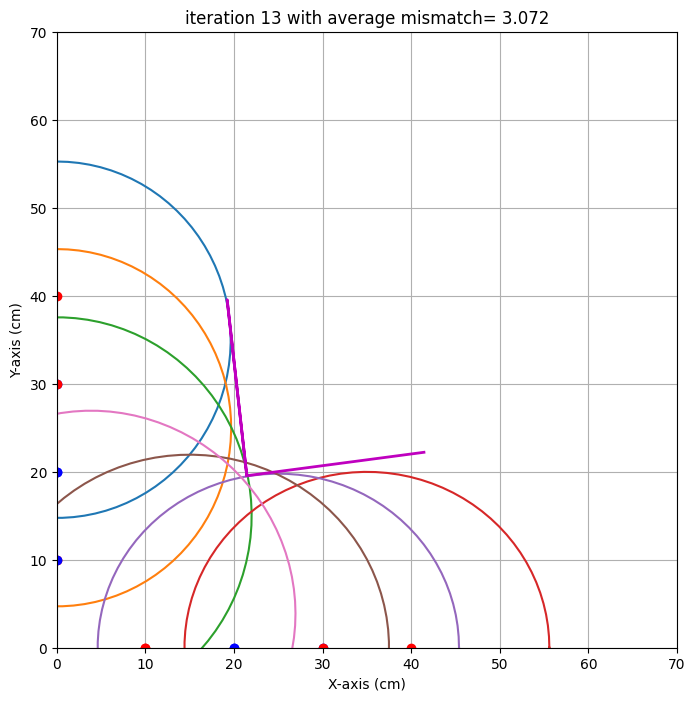

end iteration 13 with average mismatch= 3.072
end iteration 14 with average mismatch= 2.904
end iteration 15 with average mismatch= 2.716
end iteration 16 with average mismatch= 2.714
end iteration 17 with average mismatch= 2.710
end iteration 18 with average mismatch= 2.676
end iteration 19 with average mismatch= 2.675
end iteration 20 with average mismatch= 2.675
end iteration 21 with average mismatch= 2.675
end iteration 22 with average mismatch= 2.653
end iteration 23 with average mismatch= 2.653
end iteration 24 with average mismatch= 2.652
end iteration 25 with average mismatch= 2.652
end iteration 26 with average mismatch= 2.652
end iteration 27 with average mismatch= 2.651
end iteration 28 with average mismatch= 2.648
end iteration 29 with average mismatch= 2.644
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 2.636
###############################################################

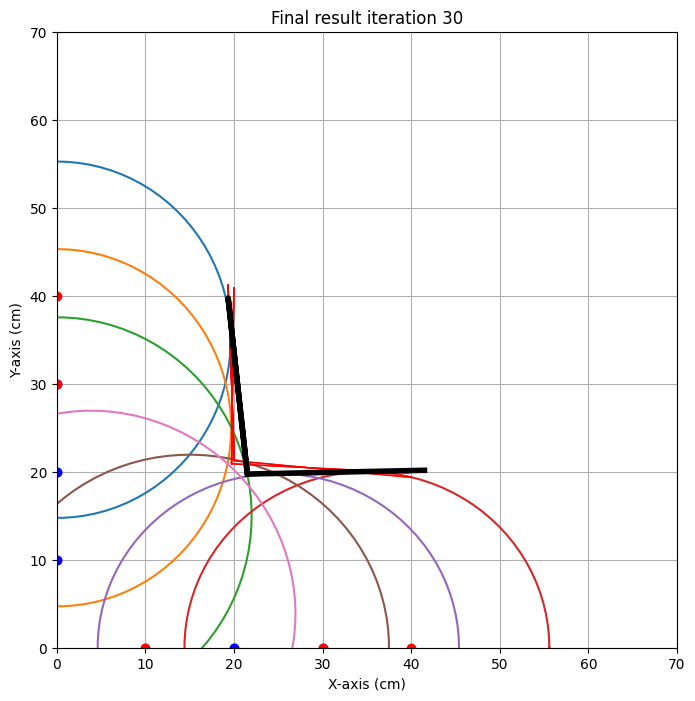

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.6],
    [0,10,0,20,45.1],
    [40,0,30,0,41.2],
    [30,0,20,0,40.8],
    [10,0,20,0,45],
    [10,0,0,10,45]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.5 cm met een standaardafwijking van 1.8 cm 
y0: 19.7 cm met een standaardafwijking van 1.5 cm 
alpha: 1.2 graden met een standaardafwijking van 6.6 graad 
beta: -6.2 graden met een standaardafwijking van 6.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Sriman]

<img src="Alg1.jpeg" width="400">

#### algoritme [Juraj]

<img src="Alg2.jpeg" width="400">

#### algoritme [Carsten]

<img src="Alg3.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,
           'y0':20,
           'alpha' : 10,
           'beta' : 5,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
       'Sriman' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [25,0,40,0,43.58],
    [25,0,35,0,43.39],
    [25,0,30,0,41.60],
    [0,25,0,40,43.80],
    [0,25,0,35,41.38],
    [0,25,0,30,39.90]
    ]),
       'Juraj' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,45,0,45.9],
    [35,0,40,0,43.8],
    [30,0,35,0,42.2],
    [25,0,30,0,40.9],
    [0,40,0,45,41.7],
    [0,35,0,40,40.8],
    [0,30,0,35,40.1],
    [0,25,0,30,39.3]
    ])
      }

## Opdracht 7: Evaluatie.

Sriman
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  25   0  40   0  43.58
1  25   0  35   0  43.39
2  25   0  30   0  41.60
3   0  25   0  40  43.80
4   0  25   0  35  41.38
5   0  25   0  30  39.90


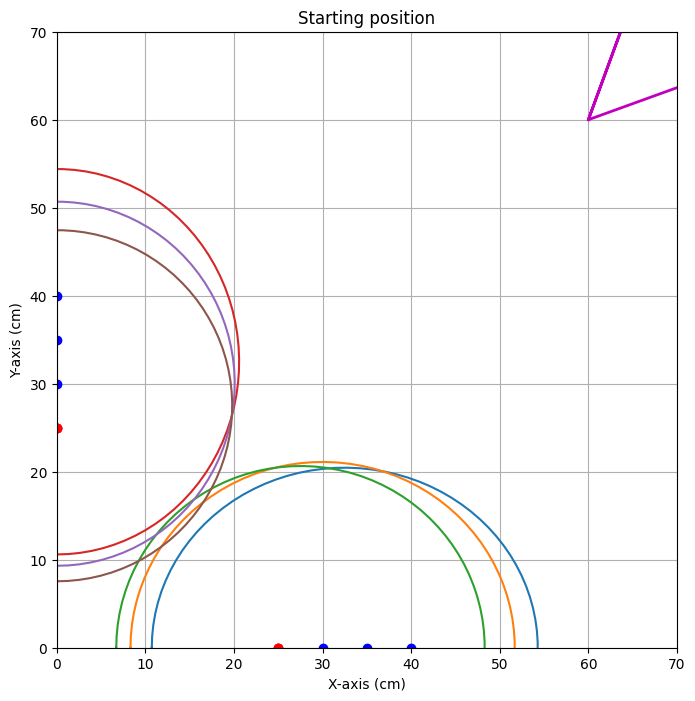


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.505


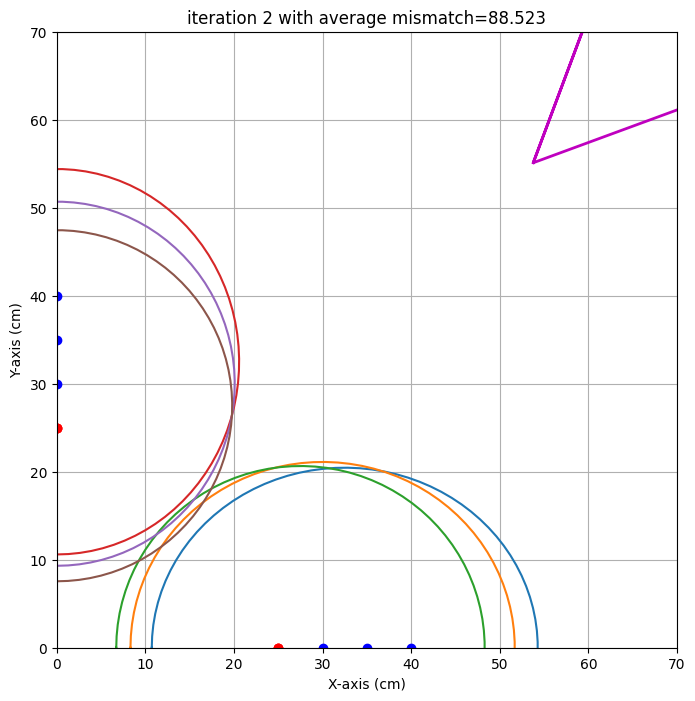

end iteration 2 with average mismatch=88.523


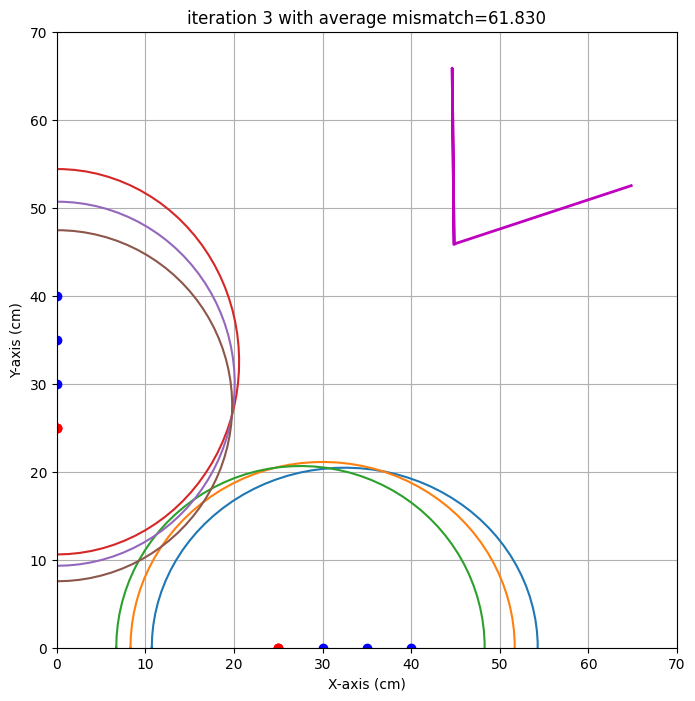

end iteration 3 with average mismatch=61.830


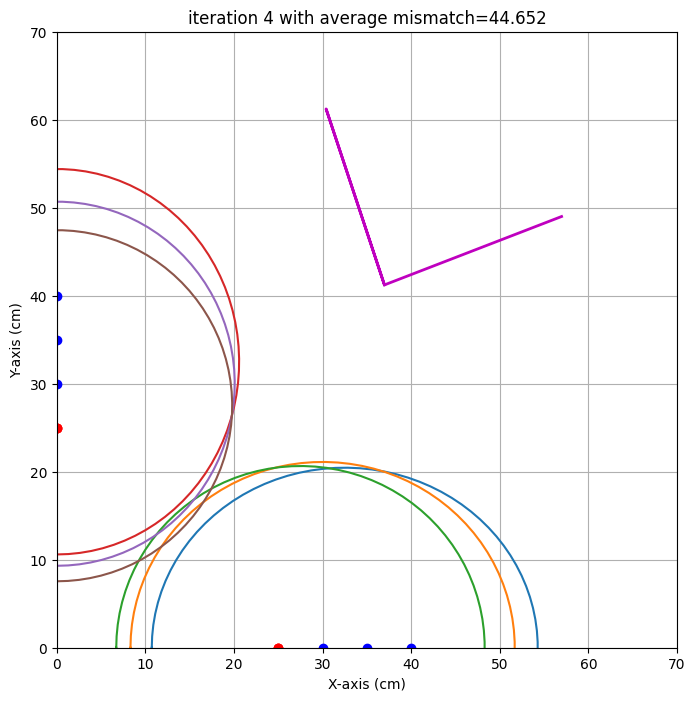

end iteration 4 with average mismatch=44.652


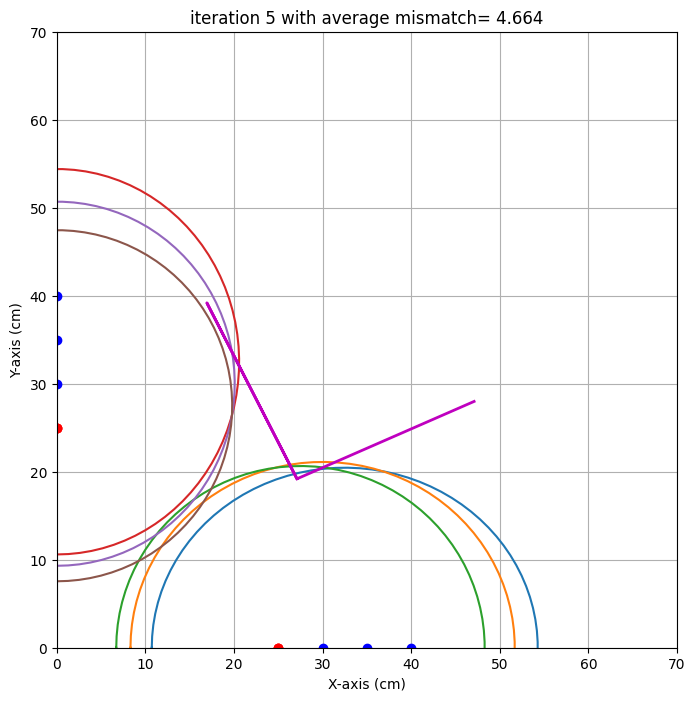

end iteration 5 with average mismatch= 4.664


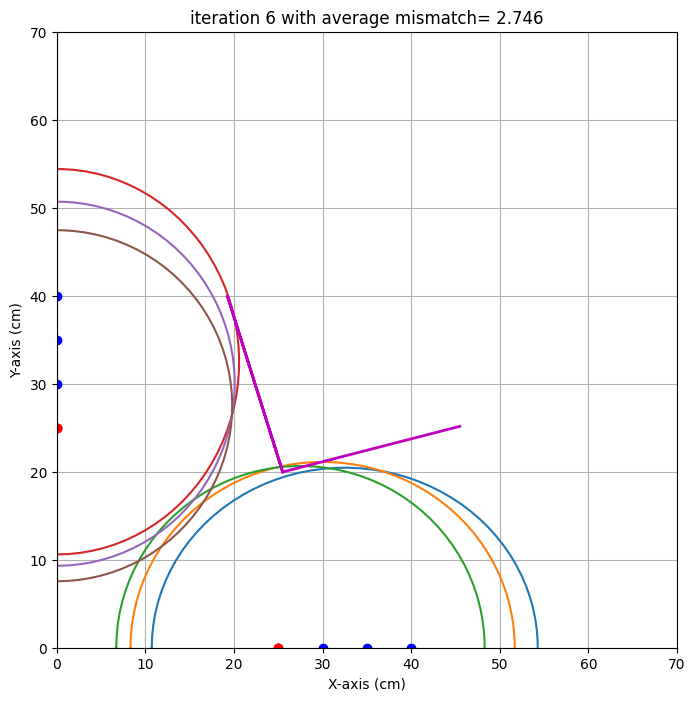

end iteration 6 with average mismatch= 2.746


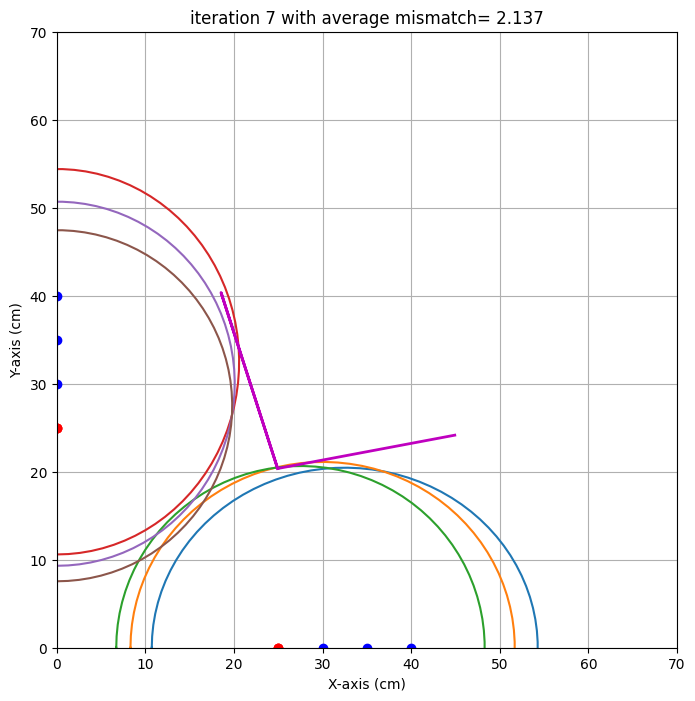

end iteration 7 with average mismatch= 2.137


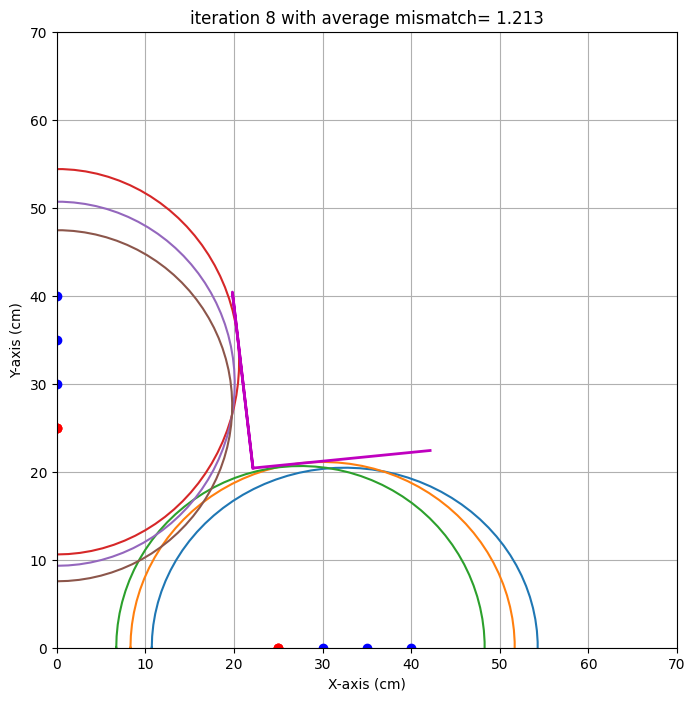

end iteration 8 with average mismatch= 1.213


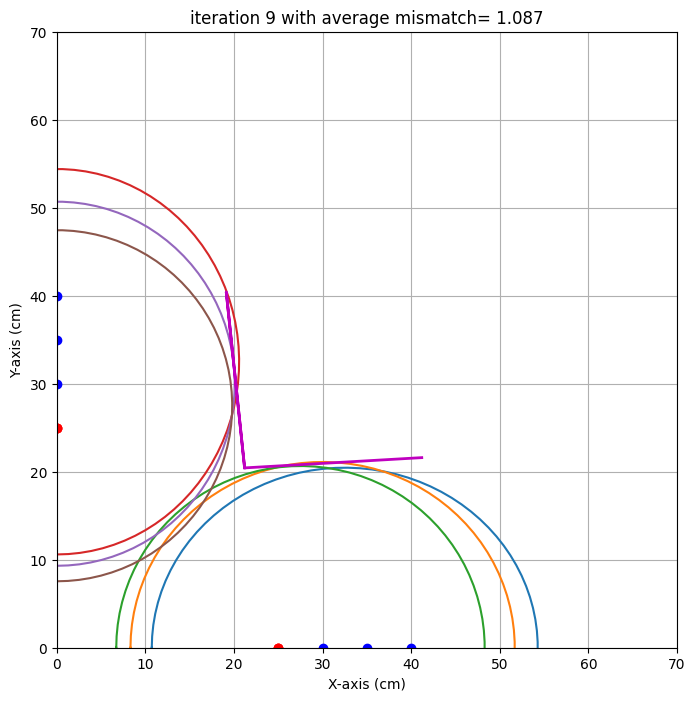

end iteration 9 with average mismatch= 1.087
end iteration 10 with average mismatch= 1.086
end iteration 11 with average mismatch= 1.086
end iteration 12 with average mismatch= 1.086
end iteration 13 with average mismatch= 1.086
end iteration 14 with average mismatch= 1.086
end iteration 15 with average mismatch= 1.086
end iteration 16 with average mismatch= 1.086
end iteration 17 with average mismatch= 1.086
end iteration 18 with average mismatch= 1.086
end iteration 19 with average mismatch= 1.086
end iteration 20 with average mismatch= 1.086
end iteration 21 with average mismatch= 1.086
end iteration 22 with average mismatch= 1.086
end iteration 23 with average mismatch= 1.086
end iteration 24 with average mismatch= 1.083
end iteration 25 with average mismatch= 1.051
end iteration 26 with average mismatch= 1.048
end iteration 27 with average mismatch= 1.048
end iteration 28 with average mismatch= 1.048
end iteration 29 with average mismatch= 1.048
Last iteration, also determine unce

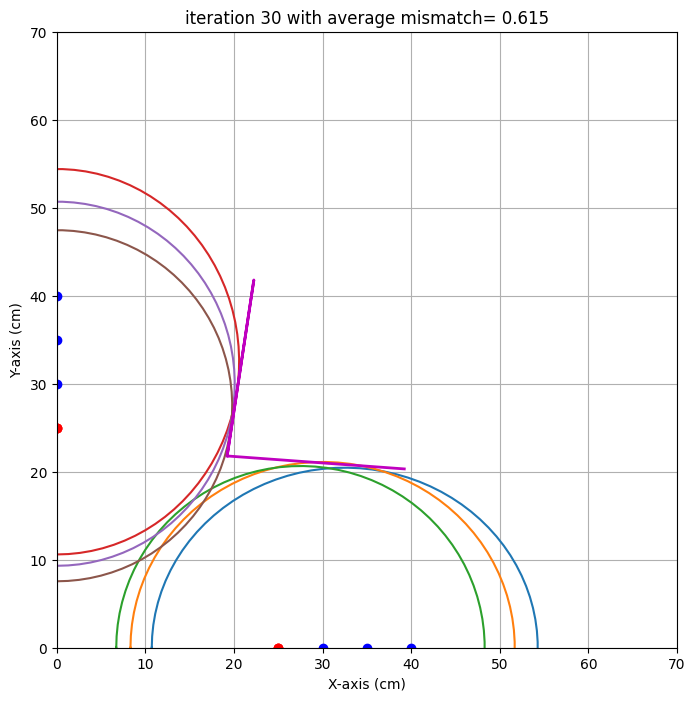

end iteration 30 with average mismatch= 0.615
###############################################################################
end of iteration  30
Best alpha=  -4.21 with uncertainty=  11.49
Best beta =   8.58 with uncertainty=   8.42
Best x0   =  19.22 with uncertainty=   1.06
Best y0   =  21.79 with uncertainty=   2.00
###############################################################################


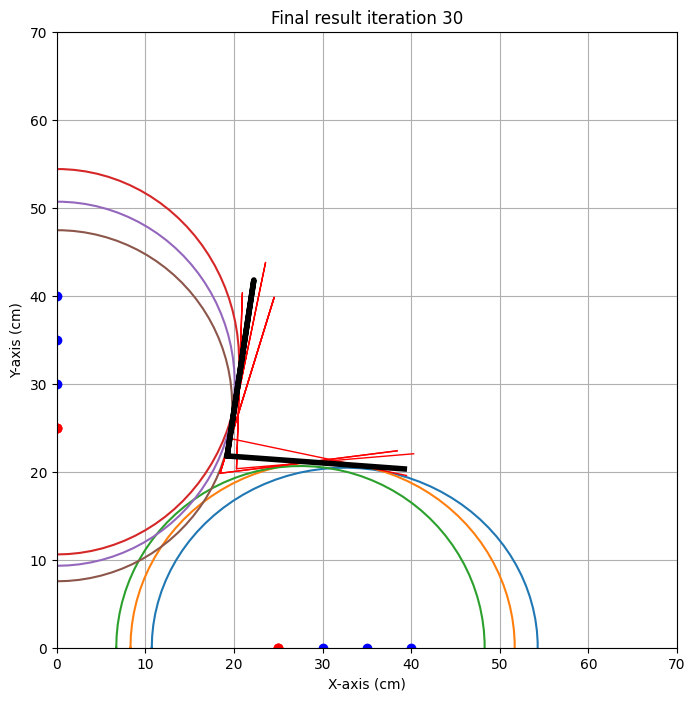

{'alpha': np.float64(-4.206821625017261), 'alpha_eps': np.float64(11.485035581358275), 'beta': np.float64(8.581758812430808), 'beta_eps': np.float64(8.42036272749944), 'x0': np.float64(19.21949521205256), 'x0_eps': np.float64(1.0593149374399928), 'y0': np.float64(21.790235689108652), 'y0_eps': np.float64(2.000842509786416)}
Juraj
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  45   0  45.9
1  35   0  40   0  43.8
2  30   0  35   0  42.2
3  25   0  30   0  40.9
4   0  40   0  45  41.7
5   0  35   0  40  40.8
6   0  30   0  35  40.1
7   0  25   0  30  39.3


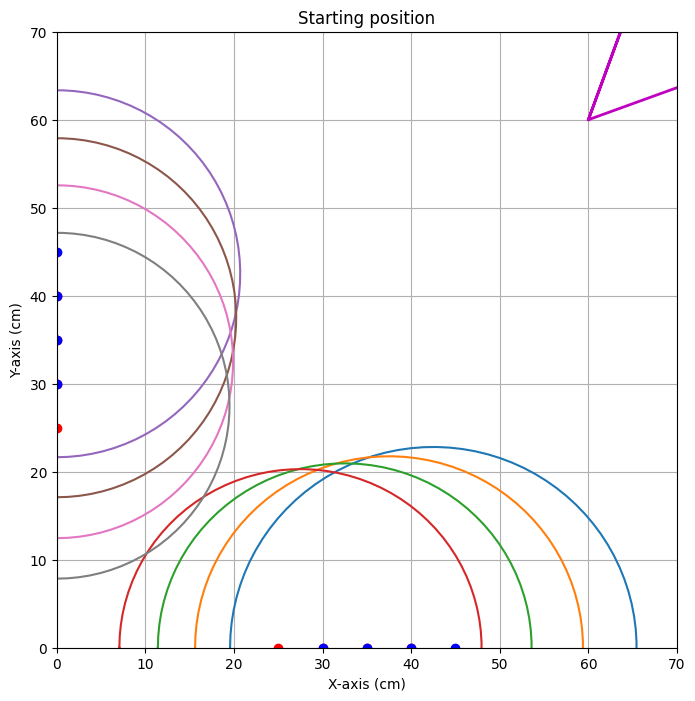


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.666


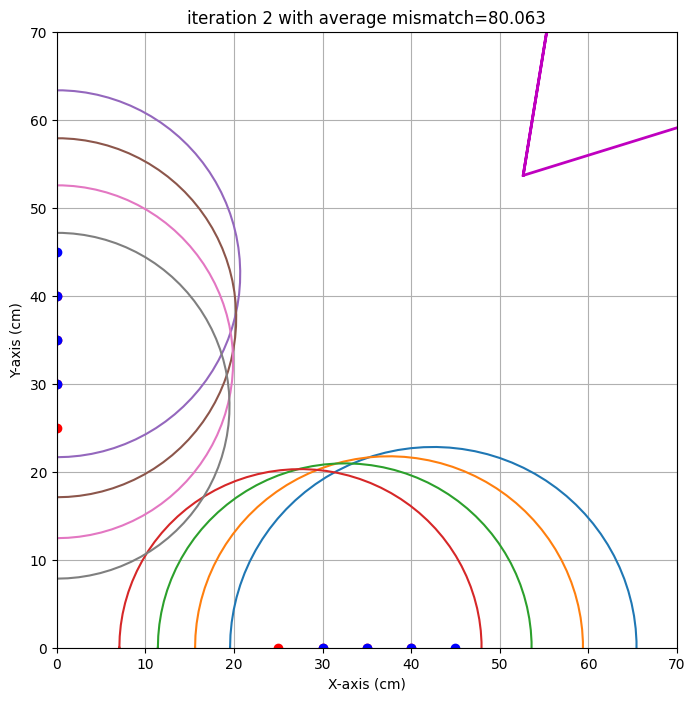

end iteration 2 with average mismatch=80.063


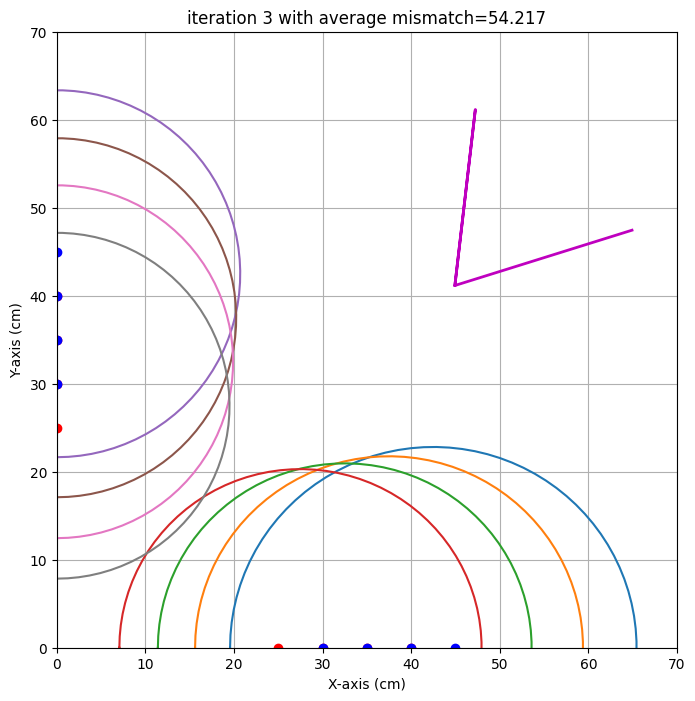

end iteration 3 with average mismatch=54.217


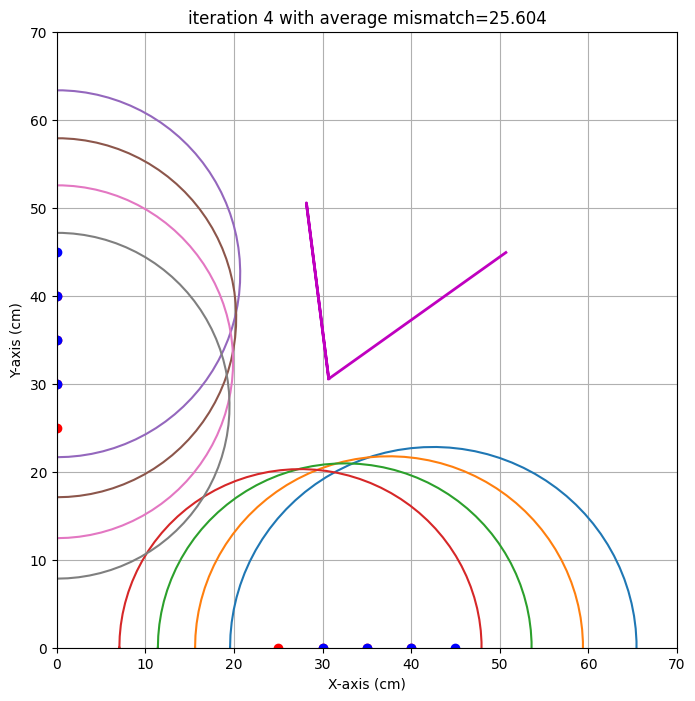

end iteration 4 with average mismatch=25.604


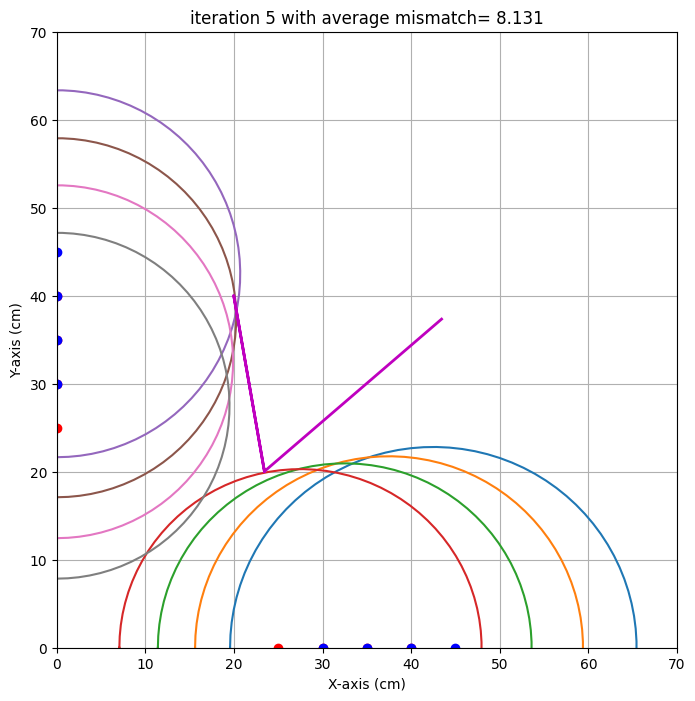

end iteration 5 with average mismatch= 8.131


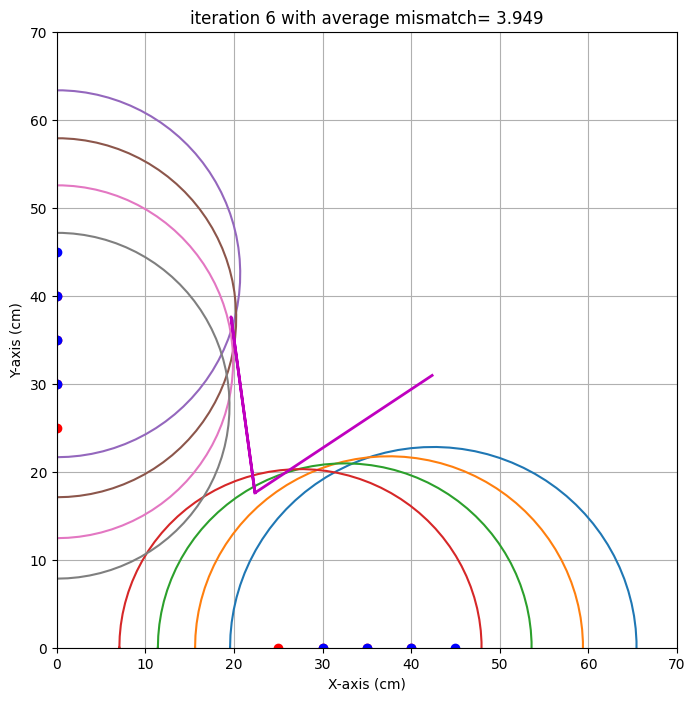

end iteration 6 with average mismatch= 3.949


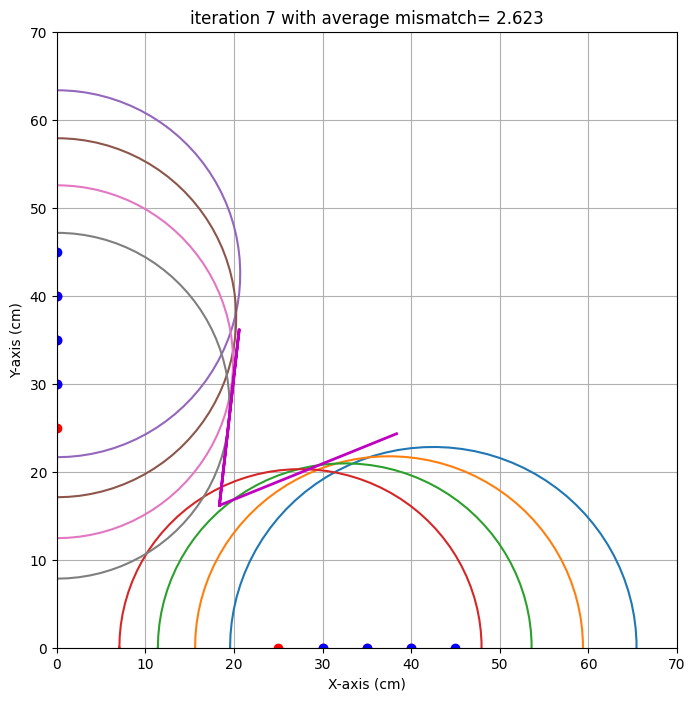

end iteration 7 with average mismatch= 2.623


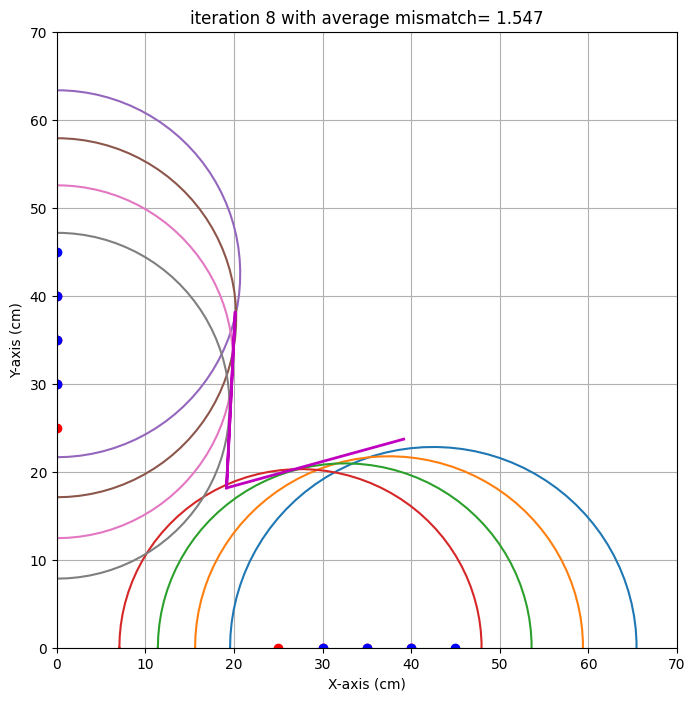

end iteration 8 with average mismatch= 1.547


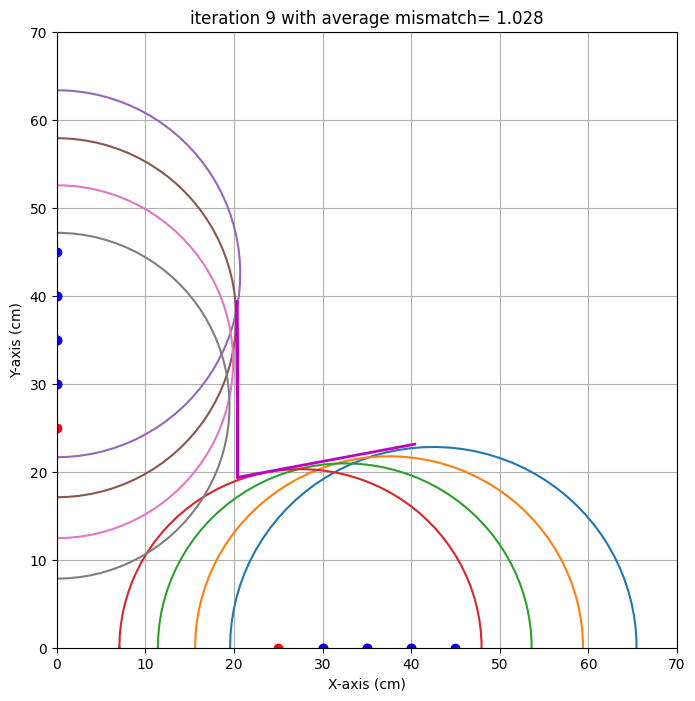

end iteration 9 with average mismatch= 1.028
end iteration 10 with average mismatch= 0.964


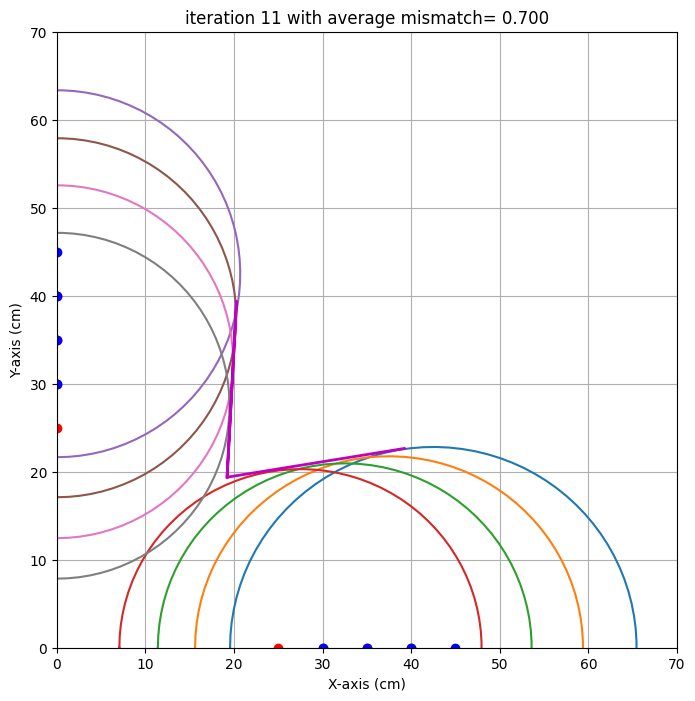

end iteration 11 with average mismatch= 0.700
end iteration 12 with average mismatch= 0.638
end iteration 13 with average mismatch= 0.626
end iteration 14 with average mismatch= 0.622
end iteration 15 with average mismatch= 0.621
end iteration 16 with average mismatch= 0.621
end iteration 17 with average mismatch= 0.621
end iteration 18 with average mismatch= 0.621
end iteration 19 with average mismatch= 0.621
end iteration 20 with average mismatch= 0.621
end iteration 21 with average mismatch= 0.621
end iteration 22 with average mismatch= 0.621
end iteration 23 with average mismatch= 0.621
end iteration 24 with average mismatch= 0.621
end iteration 25 with average mismatch= 0.621
end iteration 26 with average mismatch= 0.621
end iteration 27 with average mismatch= 0.621
end iteration 28 with average mismatch= 0.621
end iteration 29 with average mismatch= 0.621
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

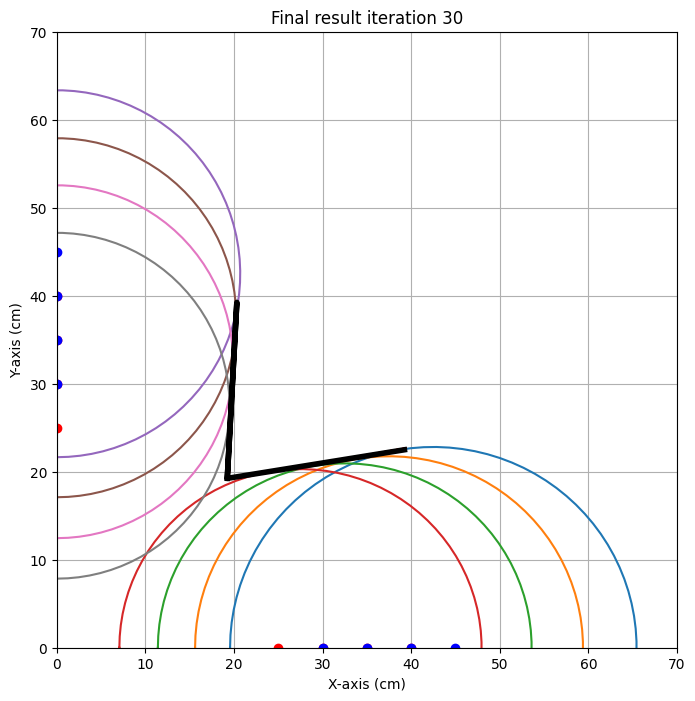

{'alpha': np.float64(9.226855542031945), 'alpha_eps': np.float64(0.43535668313938913), 'beta': np.float64(3.09731699344117), 'beta_eps': np.float64(0.8498852714258183), 'x0': np.float64(19.234103829472843), 'x0_eps': np.float64(0.21047149467002058), 'y0': np.float64(19.245240414524243), 'y0_eps': np.float64(0.05274044142170098)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Sriman 
x0 target is : 20.0. Gevonden waarde: 19.2 cm met een standaardafwijking van 1.1 cm 
y0 target is : 20.0. Gevonden waarde: 21.8 cm met een standaardafwijking van 2.0 cm 
alpha target is : 10.0. Gevonden waarde: -4.2 graden met een standaardafwijking van 11.5 graad 
beta target is : 5.0. Gevonden waarde: 8.6 graden met een standaardafwijking van 8.4 graad 

Juraj 
x0 target is : 20.0. Gevonden waarde: 19.2 cm met een standaardafwijking van 0.2 cm 
y0 target is : 20.0. Gevonden waarde: 19.2 cm met een standaardafwijking van 0.1 cm 
alpha target is : 10.0. Gevonden waarde: 9.2 graden met een standaardafwijking van 0.4 graad 
beta target is : 5.0. Gevonden waarde: 3.1 graden met een standaardafwijking van 0.8 graad 



## Opdracht 8: Iteratie1+16.29.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](It_fin.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
     xs    ys    xr    yr   R
0  32.5   0.0  37.5   0.0  97
1  42.5   0.0  47.5   0.0  88
2  52.5   0.0  57.5   0.0  88
3  62.5   0.0  67.5   0.0  91
4   0.0  32.5   0.0  37.5  94
5   0.0  42.5   0.0  47.5  93
6   0.0  52.5   0.0  57.5  89
7   0.0  62.5   0.0  67.5  93


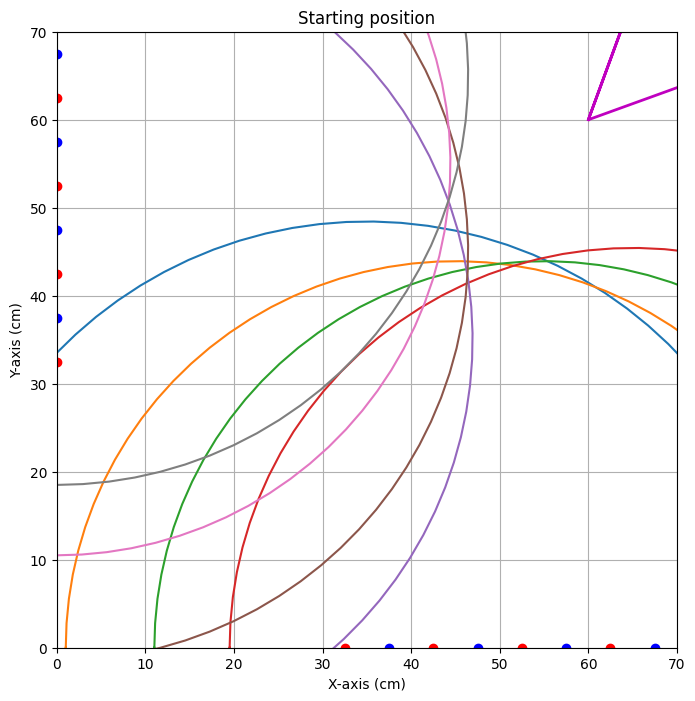


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.146


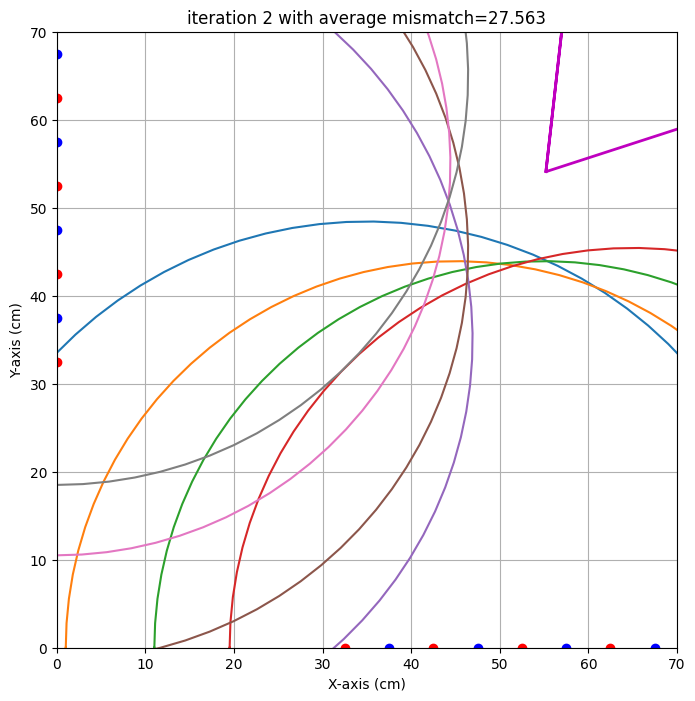

end iteration 2 with average mismatch=27.563


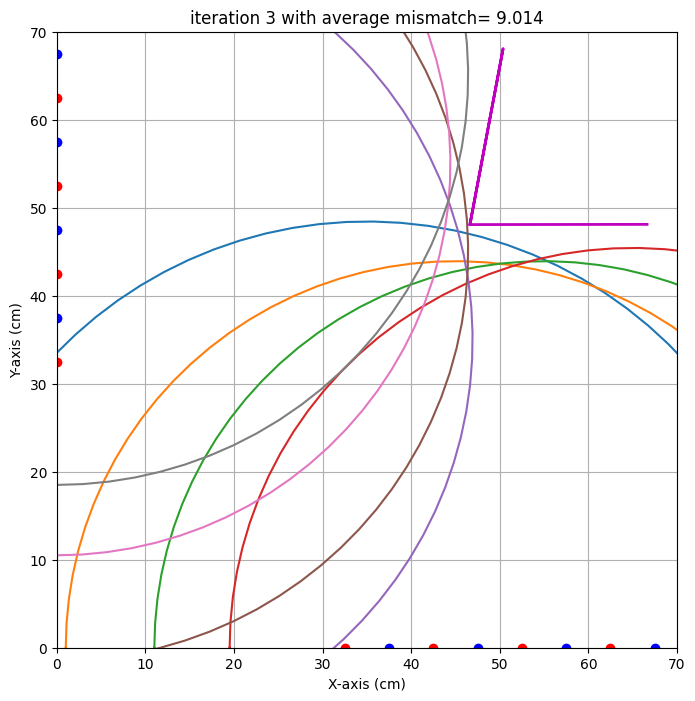

end iteration 3 with average mismatch= 9.014


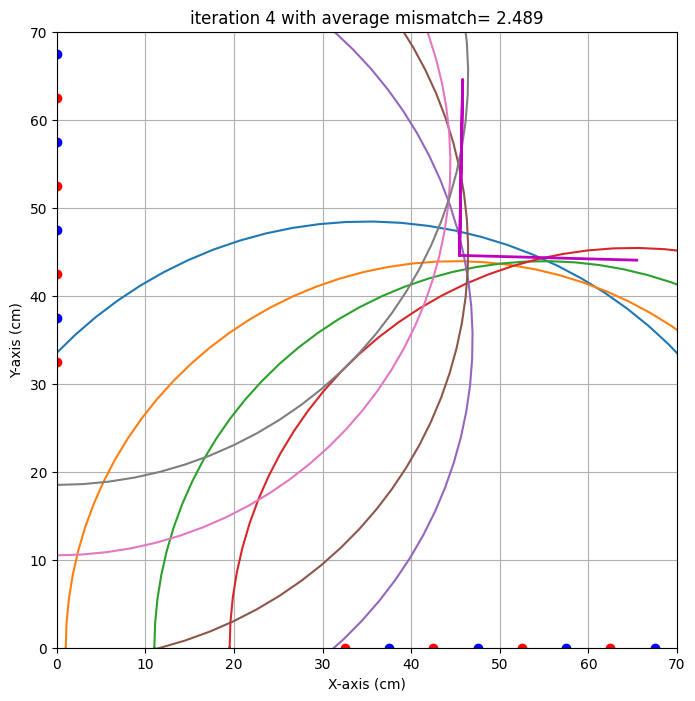

end iteration 4 with average mismatch= 2.489
end iteration 5 with average mismatch= 2.286
end iteration 6 with average mismatch= 2.244
end iteration 7 with average mismatch= 2.242
end iteration 8 with average mismatch= 2.242
end iteration 9 with average mismatch= 2.242
end iteration 10 with average mismatch= 2.227
end iteration 11 with average mismatch= 2.227
end iteration 12 with average mismatch= 2.227
end iteration 13 with average mismatch= 2.227
end iteration 14 with average mismatch= 2.227
end iteration 15 with average mismatch= 2.227
end iteration 16 with average mismatch= 2.205
end iteration 17 with average mismatch= 2.205
end iteration 18 with average mismatch= 2.205
end iteration 19 with average mismatch= 2.205
end iteration 20 with average mismatch= 2.205
end iteration 21 with average mismatch= 2.205
end iteration 22 with average mismatch= 2.196
end iteration 23 with average mismatch= 2.196
end iteration 24 with average mismatch= 2.196
end iteration 25 with average mismatch= 

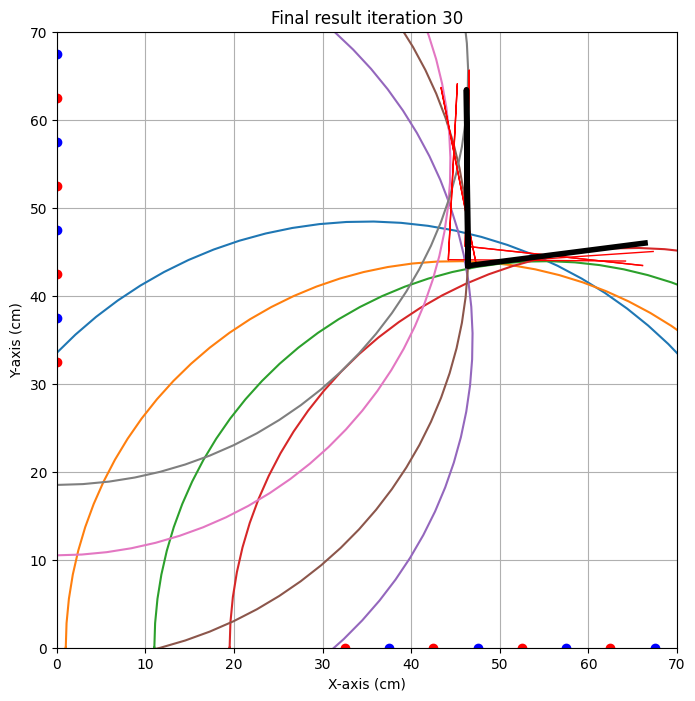

{'alpha': np.float64(7.336234702772868), 'alpha_eps': np.float64(13.590729901755866), 'beta': np.float64(-0.47743299683445967), 'beta_eps': np.float64(10.702521472300633), 'x0': np.float64(46.40547651476098), 'x0_eps': np.float64(2.212166518895252), 'y0': np.float64(43.41033204194347), 'y0_eps': np.float64(2.216773452828882)}
locatie 2
Running the imaging algorithm with the following data:
     xs    ys    xr    yr   R
0  32.5   0.0  37.5   0.0  56
1  42.5   0.0  47.5   0.0  59
2  52.5   0.0  57.5   0.0  63
3   0.0  32.5   0.0  37.5  58
4   0.0  42.5   0.0  47.5  61
5   0.0  52.5   0.0  57.5  65
6   0.0  22.5   0.0  27.5  61


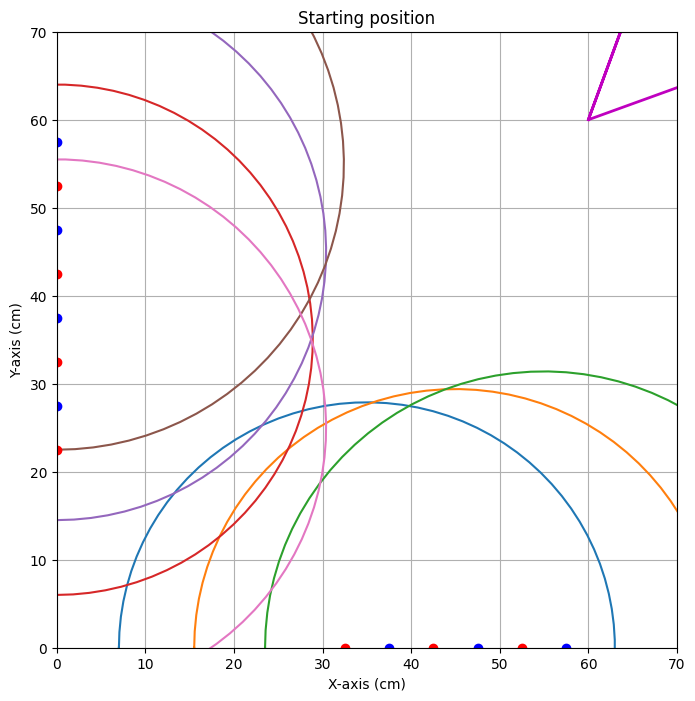


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.779


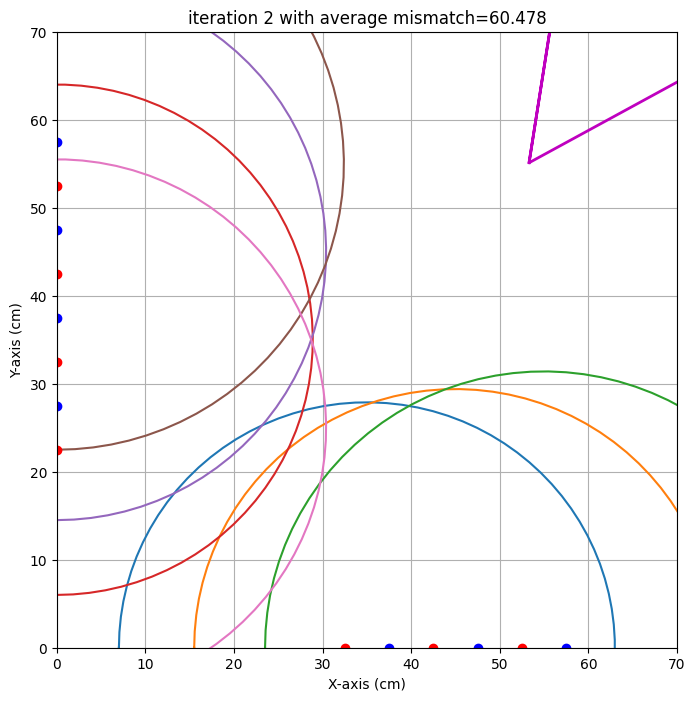

end iteration 2 with average mismatch=60.478


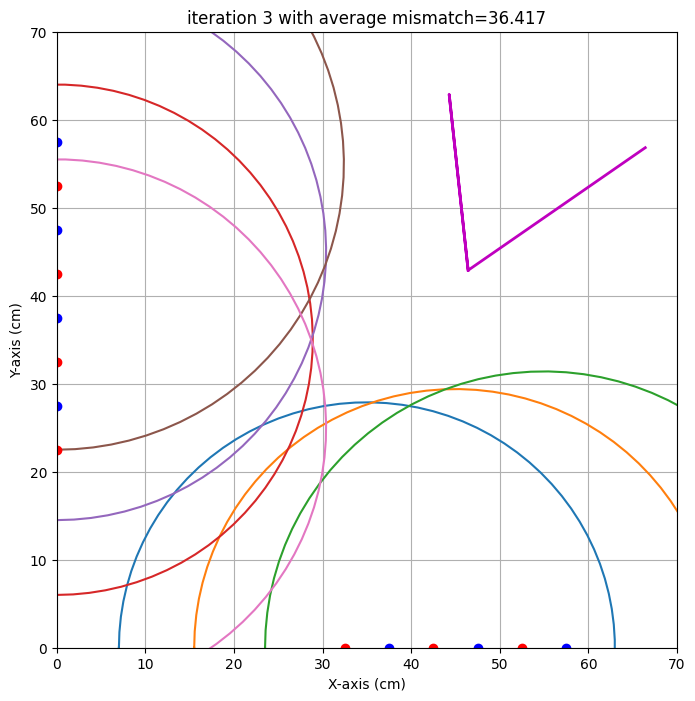

end iteration 3 with average mismatch=36.417


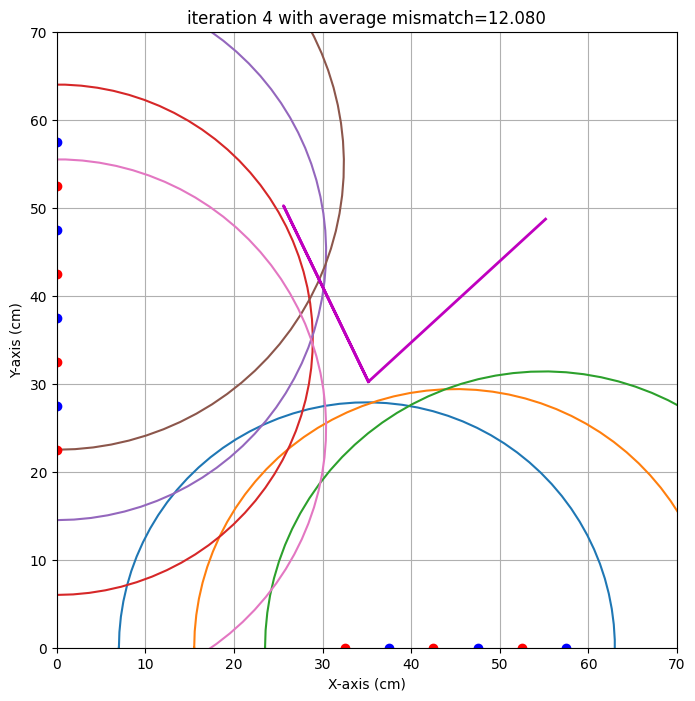

end iteration 4 with average mismatch=12.080


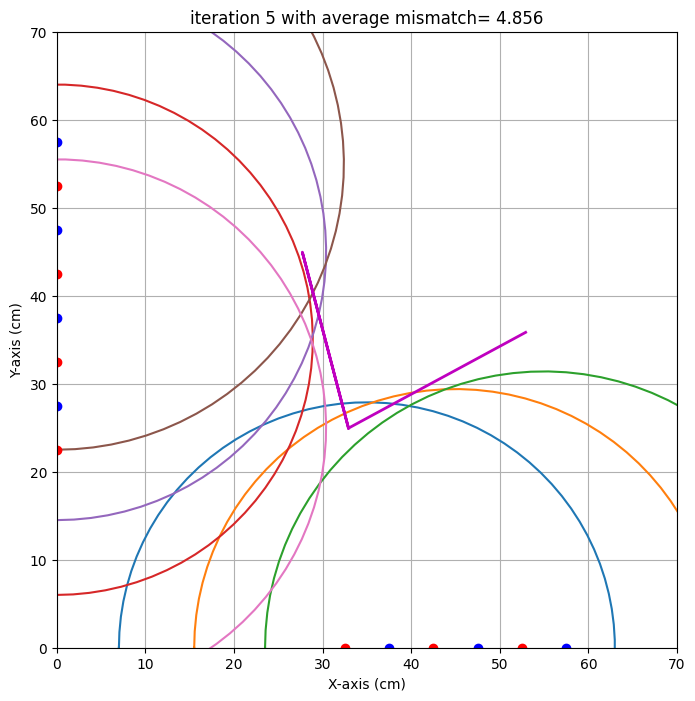

end iteration 5 with average mismatch= 4.856


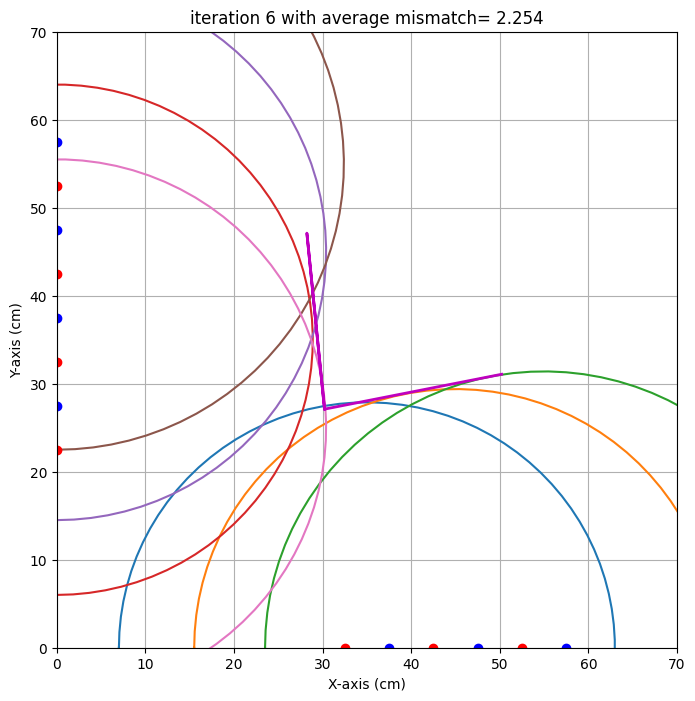

end iteration 6 with average mismatch= 2.254
end iteration 7 with average mismatch= 2.193


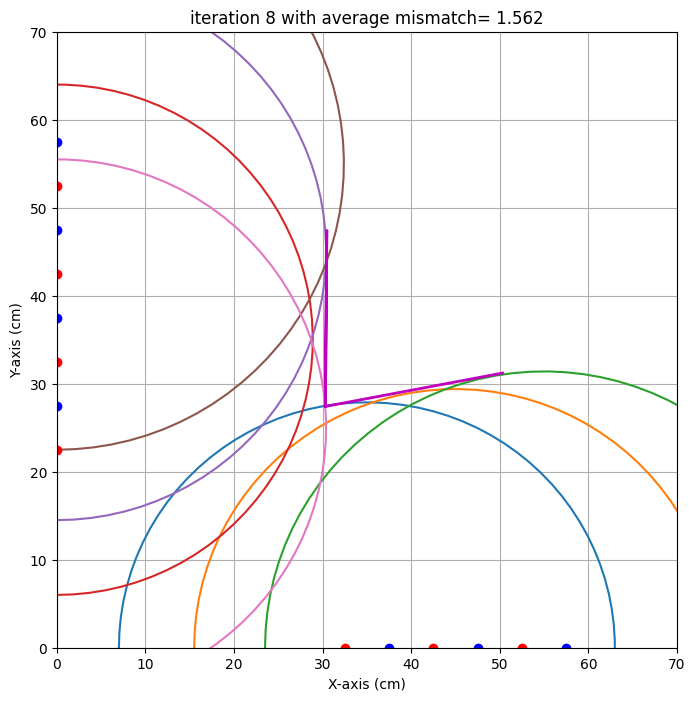

end iteration 8 with average mismatch= 1.562
end iteration 9 with average mismatch= 1.549
end iteration 10 with average mismatch= 1.548
end iteration 11 with average mismatch= 1.548
end iteration 12 with average mismatch= 1.508
end iteration 13 with average mismatch= 1.476
end iteration 14 with average mismatch= 1.466
end iteration 15 with average mismatch= 1.464
end iteration 16 with average mismatch= 1.464
end iteration 17 with average mismatch= 1.464
end iteration 18 with average mismatch= 1.464
end iteration 19 with average mismatch= 1.464
end iteration 20 with average mismatch= 1.464
end iteration 21 with average mismatch= 1.464
end iteration 22 with average mismatch= 1.464
end iteration 23 with average mismatch= 1.464
end iteration 24 with average mismatch= 1.464
end iteration 25 with average mismatch= 1.464
end iteration 26 with average mismatch= 1.464
end iteration 27 with average mismatch= 1.464
end iteration 28 with average mismatch= 1.464
end iteration 29 with average mismat

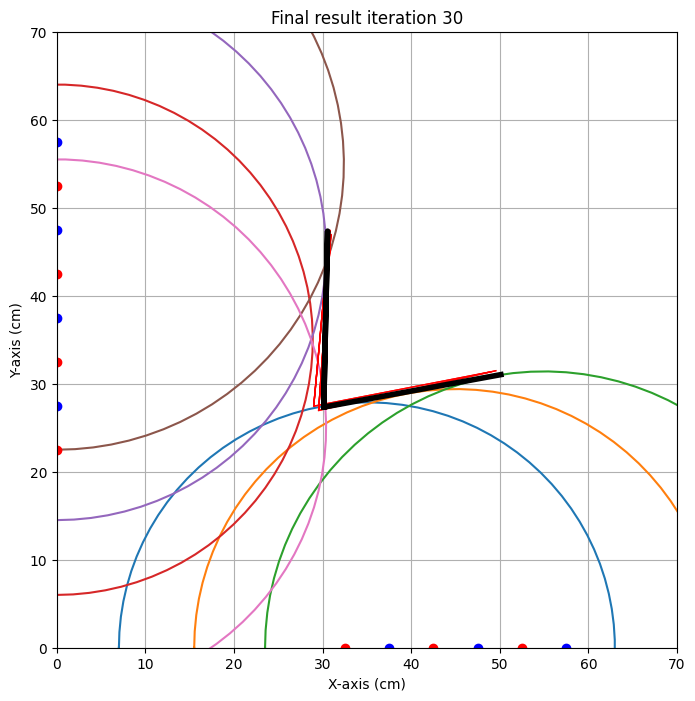

{'alpha': np.float64(10.462595494341425), 'alpha_eps': np.float64(2.2510167399702095), 'beta': np.float64(1.2340251928698078), 'beta_eps': np.float64(3.9757745932285253), 'x0': np.float64(30.12716909221974), 'x0_eps': np.float64(1.1336451132389378), 'y0': np.float64(27.340939495534162), 'y0_eps': np.float64(0.3759261685097073)}
locatie 1 
x0 target is : 44.0. Gevonden waarde: 46.4 cm met een standaardafwijking van 2.2 cm 
y0 target is : 43.8. Gevonden waarde: 43.4 cm met een standaardafwijking van 2.2 cm 
alpha target is : 10.0. Gevonden waarde: 7.3 graden met een standaardafwijking van 13.6 graad 
beta target is : 15.0. Gevonden waarde: -0.5 graden met een standaardafwijking van 10.7 graad 

locatie 2 
x0 target is : 28.4. Gevonden waarde: 30.1 cm met een standaardafwijking van 1.1 cm 
y0 target is : 28.6. Gevonden waarde: 27.3 cm met een standaardafwijking van 0.4 cm 
alpha target is : 10.0. Gevonden waarde: 10.5 graden met een standaardafwijking van 2.3 graad 
beta target is : 10.0.

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':44,
                    'y0':43.8,
                    'alpha':10,
                    'beta' :15},
           'locatie 2':{'x0':28.4,
                    'y0':28.6,
                    'alpha' : 10,
                    'beta' : 10
            }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [32.5,0,37.5,0,97],
    [42.5,0,47.5,0,88],
    [52.5,0,57.5,0,88],
    [62.5,0,67.5,0,91],
    [0,32.5,0,37.5,94],
    [0,42.5,0,47.5,93],
    [0,52.5,0,57.5,89],
    [0,62.5,0,67.5,93]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [32.5,0,37.5,0,56],
    [42.5,0,47.5,0,59],
    [52.5,0,57.5,0,63],
    [0,32.5,0,37.5,58],
    [0,42.5,0,47.5,61],
    [0,52.5,0,57.5,65],
    [0,22.5,0,27.5,61]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
     xs    ys    xr    yr   R
0  32.5   0.0  37.5   0.0  48
1  42.5   0.0  47.5   0.0  50
2  22.5   0.0  27.5   0.0  48
3   0.0  37.5   0.0  32.5  52
4   0.0  47.5   0.0  42.5  54
5   0.0  27.5   0.0  52.5  51


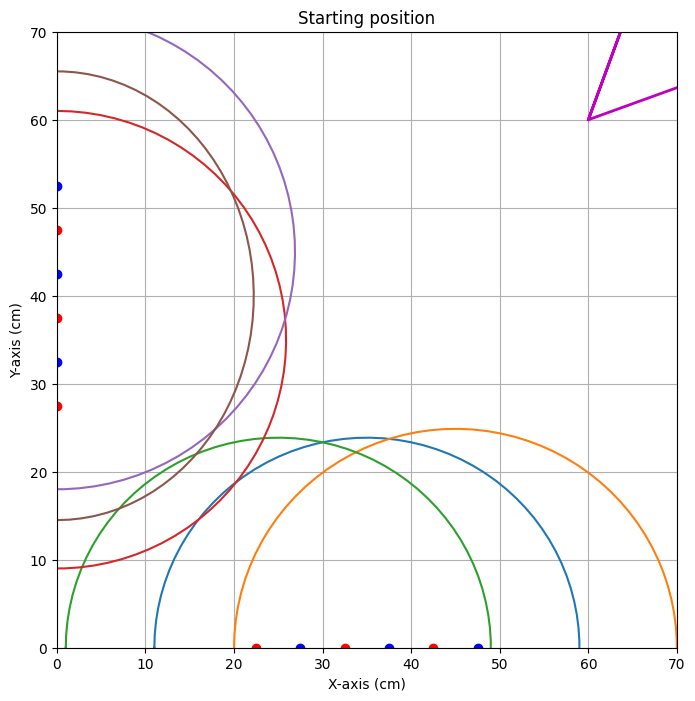


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.425


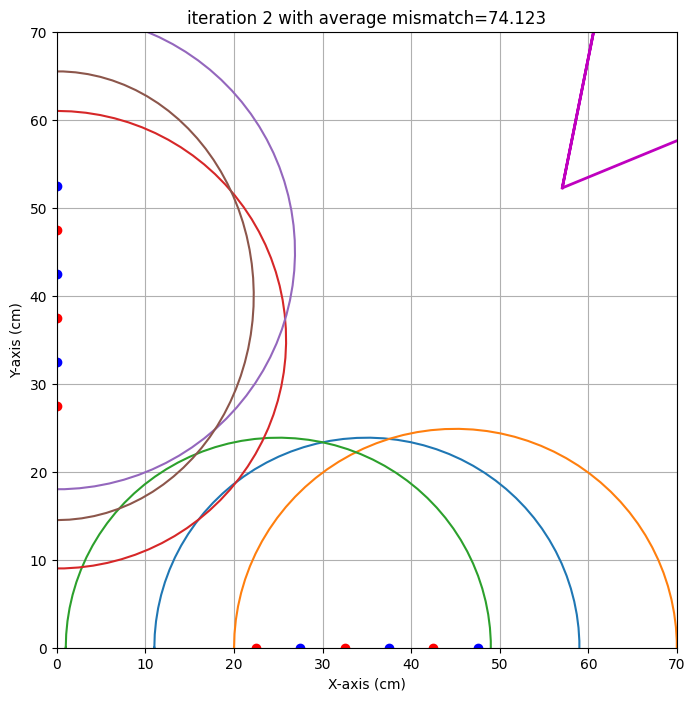

end iteration 2 with average mismatch=74.123


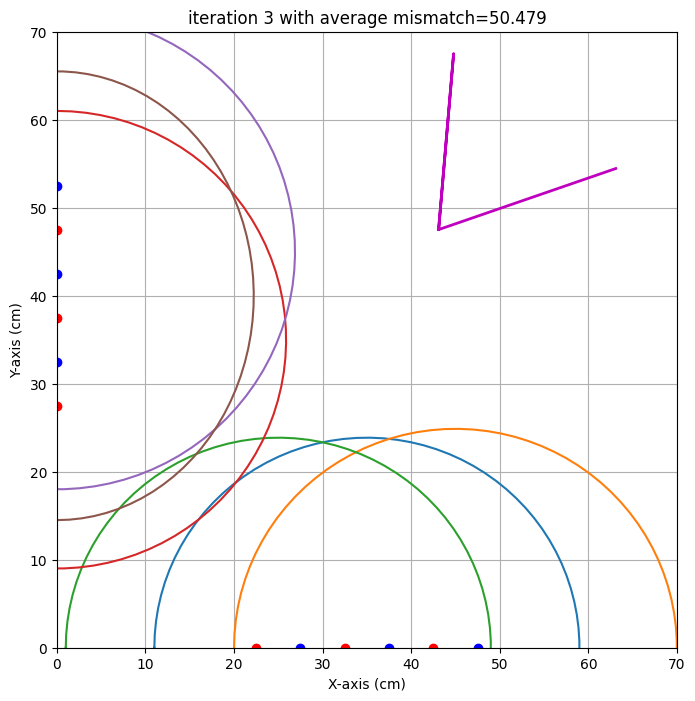

end iteration 3 with average mismatch=50.479


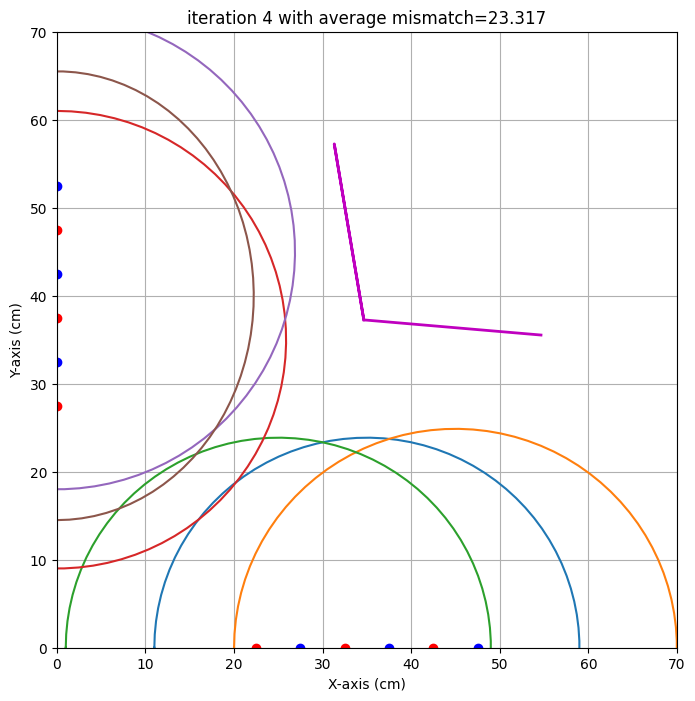

end iteration 4 with average mismatch=23.317


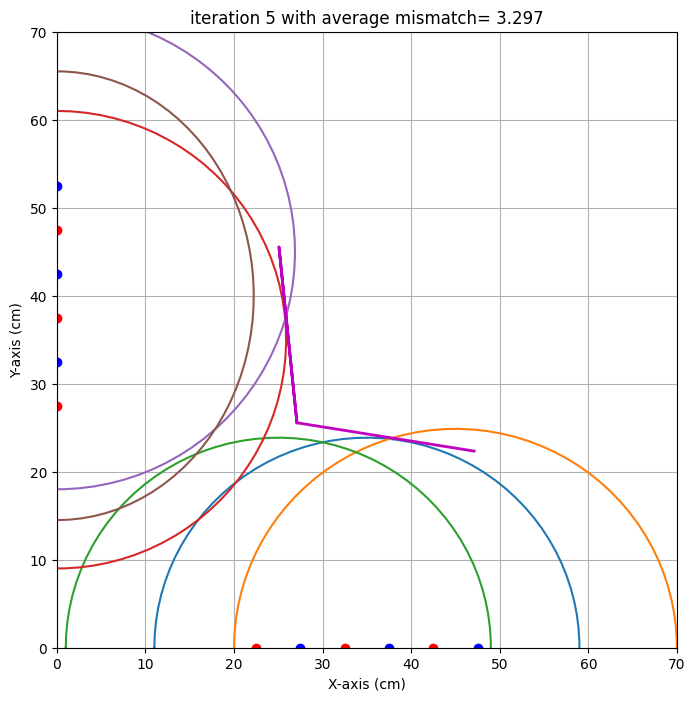

end iteration 5 with average mismatch= 3.297
end iteration 6 with average mismatch= 3.146
end iteration 7 with average mismatch= 3.091
end iteration 8 with average mismatch= 3.089
end iteration 9 with average mismatch= 3.022
end iteration 10 with average mismatch= 3.022


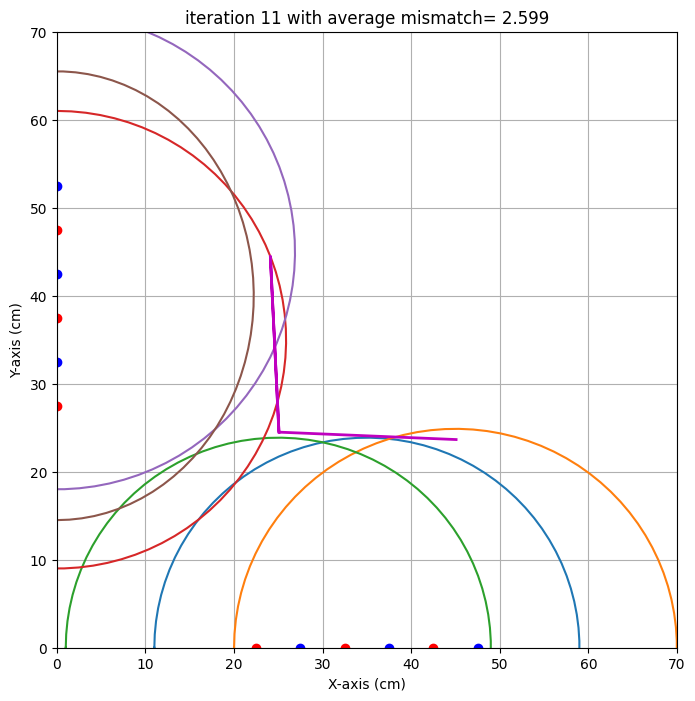

end iteration 11 with average mismatch= 2.599
end iteration 12 with average mismatch= 2.364


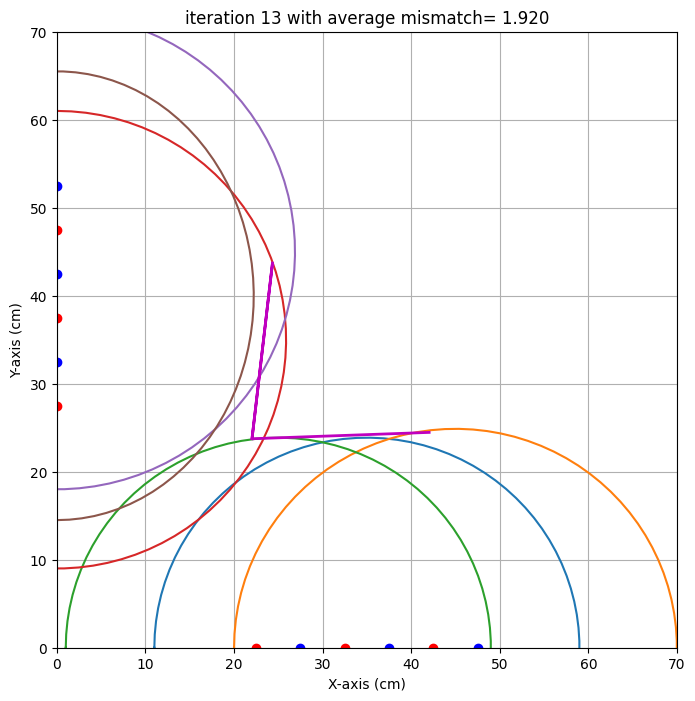

end iteration 13 with average mismatch= 1.920
end iteration 14 with average mismatch= 1.904
end iteration 15 with average mismatch= 1.804
end iteration 16 with average mismatch= 1.795
end iteration 17 with average mismatch= 1.795
end iteration 18 with average mismatch= 1.795
end iteration 19 with average mismatch= 1.795
end iteration 20 with average mismatch= 1.795
end iteration 21 with average mismatch= 1.795
end iteration 22 with average mismatch= 1.795
end iteration 23 with average mismatch= 1.795
end iteration 24 with average mismatch= 1.745
end iteration 25 with average mismatch= 1.745
end iteration 26 with average mismatch= 1.745
end iteration 27 with average mismatch= 1.745
end iteration 28 with average mismatch= 1.745
end iteration 29 with average mismatch= 1.745
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.745
###############################################################

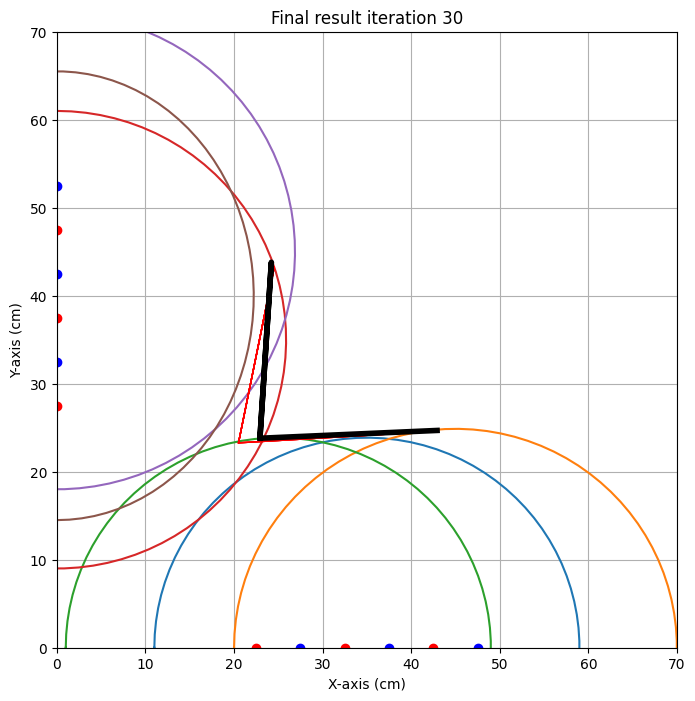

{'alpha': np.float64(2.5355373687893277), 'alpha_eps': np.float64(0.8246177796188858), 'beta': np.float64(3.6930375743298365), 'beta_eps': np.float64(7.734821755934109), 'x0': np.float64(22.92159270035603), 'x0_eps': np.float64(2.4185592846577784), 'y0': np.float64(23.80504139456147), 'y0_eps': np.float64(0.5243729696102477)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 22.9 cm met een standaardafwijking van 2.4 cm 
y0 target is : 23.5. Gevonden waarde: 23.8 cm met een standaardafwijking van 0.5 cm 
alpha target is : 5.0. Gevonden waarde: 2.5 graden met een standaardafwijking van 0.8 graad 
beta target is : 8.0. Gevonden waarde: 3.7 graden met een standaardafwijking van 7.7 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25 ,
                    'y0': 23.5  ,
                    'alpha' :5  ,
                    'beta' :8  
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [32.5,0,37.5,0,48],
    [42.5,0,47.5,0,50],
    [22.5,0,27.5,0,48],
    [0,37.5,0,32.5,52],
    [0,47.5,0,42.5,54],
    [0,27.5,0,52.5,51]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Een verklaring voor de grote onzekerheid in beta zou slechte metingen aan de y-kant kunnen zijn. In de grafiek zie je hele slechte raakpunten van de ellipsen aan de y-kant. 


Een verklaring voor de grote onzekerheid in x zou ook door slechte metingen aan de y-kant kunnen zijn. Je ziet meerdere ellipsen het object kruisen in plaats van raken.


Ook waren de metingen 30 sec voor sluitingstijd gemaakt in haast waardoor we niet goed in de seriele monitor konden kijken.


Daarnaast zijn de waarden voor R gehele getallen. Paar decimalen zou het wat nauwkeuriger hebben gemaakt.


Misschien zou iets meer verspreid meten aan de y-kant wat betere resultaten hebben geleverd, dat de lijn door de meetpunten duidelijker getrokken kan worden door het programma.

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](Alg1.jpeg "Iteratie0")

Figuur: ![Alt](Alg2.jpeg "Iteratie0")

Figuur: ![Alt](Alg3.jpeg "Iteratie0")

Figuur: ![Alt](It_fin.jpeg "Iteratiefinal")
